In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [57]:
df = pd.read_csv('/kaggle/input/datasets/harshtruth/winedataset/wine_dataset.csv')

print('Rows, Columns:', df.shape)
df.head()

Rows, Columns: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


We choose:
- **alcohol** — alcohol content of the wine
- **total_phenols** — amount of phenols
- **flavanoids** — a type of phenol

We want to predict **target** — which is the wine class (0, 1, or 2).

In [58]:
X = df[['alcohol', 'total_phenols', 'flavanoids']]

y = df['target']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (178, 3)
y shape: (178,)


Splitting data into training and testing. Standard 80:20 split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', X_train.shape[0])
print('Testing rows :', X_test.shape[0])

Training rows: 142
Testing rows : 36


In [60]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Intercept :', round(model.intercept_, 4))
print('Coefficient for alcohol      :', round(model.coef_[0], 4))
print('Coefficient for total_phenols:', round(model.coef_[1], 4))
print('Coefficient for flavanoids   :', round(model.coef_[2], 4))

Intercept : 3.8156
Coefficient for alcohol      : -0.139
Coefficient for total_phenols: 0.1708
Coefficient for flavanoids   : -0.7181


The model learned this formula:

```
predicted_target = intercept
                 + (coef_alcohol      * alcohol)
                 + (coef_total_phenols * total_phenols)
                 + (coef_flavanoids   * flavanoids)
```

In [61]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MSE :', round(mse, 4))
print('R²  :', round(r2, 4))

MSE : 0.1422
R²  : 0.7562


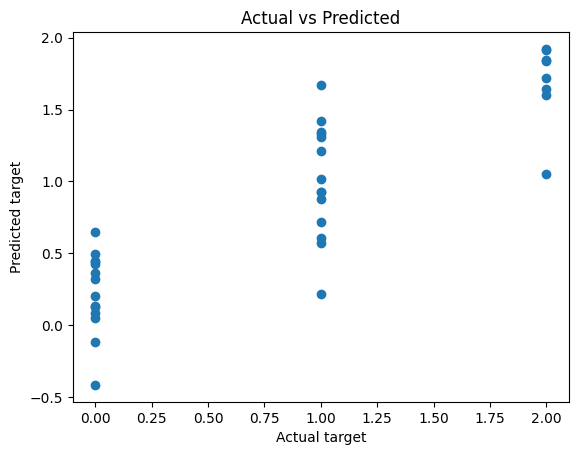

In [62]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual target')
plt.ylabel('Predicted target')
plt.title('Actual vs Predicted')
plt.show()

CHECKING IF ONE COLUMN IS A SCALAR MULTIPLE OF ANOTHER, 
WE need to find out ways to check that
I came across 3 methods

Correlation -
Correlation tells us how linearly related two columns are.
- Value close to **1** → strong positive relationship
- Value close to **0** → no relationship
- Value close to **-1** → strong negative relationship

Ratio check -
We divide two columns and look at how much the result varies everytime ( literally ratio)

Scatter plot-
If two columns are a true scalar multiple, their scatter plot will be a perfectly straight line through the origin (0, 0)

For a perfect scalar multiple , 
correlation = 1.0
ratio std (standard deviation) = 0
scatter plot = perfect straight line through origin

In [63]:
corr = df['total_phenols'].corr(df['flavanoids'])
print('Correlation between total_phenols and flavanoids:', round(corr, 4))

Correlation between total_phenols and flavanoids: 0.8646


In [64]:
ratio = df['flavanoids'] / df['total_phenols']

print('Min ratio :', round(ratio.min(), 4))
print('Max ratio :', round(ratio.max(), 4))
print('Mean ratio:', round(ratio.mean(), 4))
print('Std ratio :', round(ratio.std(), 4))

Min ratio : 0.2586
Max ratio : 1.5975
Mean ratio: 0.8437
Std ratio : 0.2828


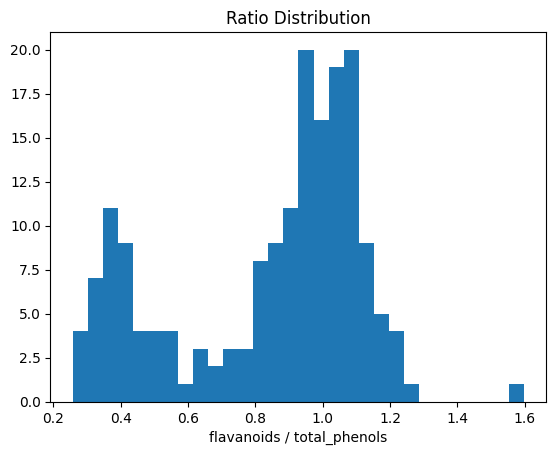

In [65]:
plt.hist(ratio, bins=30)
plt.xlabel('flavanoids / total_phenols')
plt.title('Ratio Distribution')
plt.show()

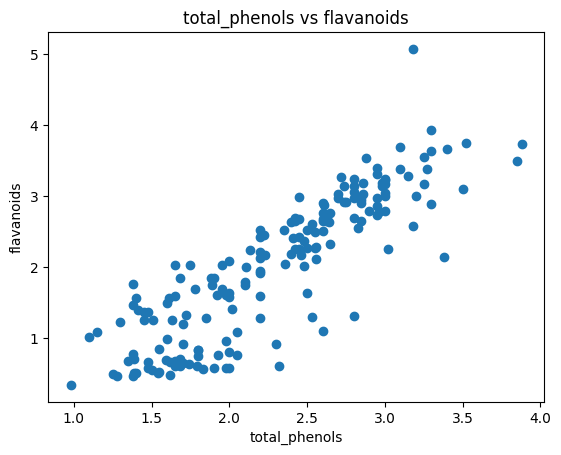

In [66]:
plt.scatter(df['total_phenols'], df['flavanoids'])
plt.xlabel('total_phenols')
plt.ylabel('flavanoids')
plt.title('total_phenols vs flavanoids')
plt.show()

WHAT HAPPENS WHEN WE DO HAVE ONE COLUMN LIKE THAT ??

When one feature is a scalar multiple of another, say flavanoids = 2 × total_phenols, the model is essentially seeing the same information twice. It can't figure out how much credit to give each one. Should it put the weight on total_phenols or on flavanoids? Both carry identical information, so there's no way to decide.
The coefficients become unstable. Instead of one clean answer, there are now infinite combinations of coefficients that give the exact same predictions. For example, these two would produce identical results:

coef_phenols = 1.0, coef_flavanoids = 0.0
coef_phenols = 0.0, coef_flavanoids = 0.5 (since flavanoids = 2 × phenols)

So the model just picks arbitrary numbers. If you retrain on slightly different data, the coefficients could completely flip — making them meaningless to interpret.
This problem is called multicollinearity.